In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tqdm import tqdm
import glob
import os

In [2]:
# --- 1. Configuration ---
RAW_DATA_DIR = "csi_data"
PCA_COMPONENTS = 50
EPOCHS = 50 
BATCH_SIZE = 32
USE_PCA = True
USE_MAGNITUDE = True
VALID_ACTIVITIES = ['sitting', 'walking', 'standing', 'sleeping', 'falling']

train_sessions_files = [
    'esp32_csi_walking_20250727_152811',
    'esp32_csi_walking_20250727_152603',
    'esp32_csi_walking_20250728_150535',
    'esp32_csi_standing_20250727_155036',
    'esp32_csi_standing_20250727_154720',
    'esp32_csi_standing_20250728_141446',
    'esp32_csi_sleeping_20250727_164127',
    'esp32_csi_sleeping_20250727_163829',
    'esp32_csi_sleeping_20250728_124410',
    'esp32_csi_sitting_20250727_161517',
    'esp32_csi_sitting_20250727_161310',
    'esp32_csi_sitting_20250728_133443',
    'esp32_csi_falling_20250727_133043',
    'esp32_csi_falling_20250727_132826',
    'esp32_csi_falling_20250728_114422'
]

val_sessions_files = [
    'esp32_csi_falling_20250727_165423',
    'esp32_csi_sitting_20250728_125939',
    'esp32_csi_sleeping_20250728_120223',
    'esp32_csi_standing_20250728_134840',
    'esp32_csi_walking_20250728_143754'
]

In [3]:
# --- 2. Data Loading and Cleaning Function ---
def load_and_clean_sessions(file_list, data_dir):
    """Loads, concatenates, and cleans a specific list of session files."""
    df_list = []
    for filename in tqdm(file_list, desc=f"Loading files for set"):
        file_path = os.path.join(data_dir, f"{filename}.csv")
        if not os.path.exists(file_path):
            print(f"[Warning] File not found: {filename}. Skipping.")
            continue
        try:
            activity_label = filename.split('_')[2]
            if activity_label in VALID_ACTIVITIES:
                temp_df = pd.read_csv(file_path)
                temp_df['activity'] = activity_label
                temp_df['session'] = filename
                df_list.append(temp_df)
        except Exception as e:
            print(f"Could not process {filename}: {e}")

    if not df_list:
        return pd.DataFrame()

    master_df = pd.concat(df_list, ignore_index=True)
    
    # Cleaning Steps
    null_subcarriers = list(range(27, 37))
    cleaned = master_df[~master_df['subcarrier_index'].isin(null_subcarriers)]
    
    magnitude_sum = cleaned.groupby(['session', 'timestamp'])['magnitude'].sum()
    dropout_indices = magnitude_sum[magnitude_sum == 0].index
    cleaned = cleaned.set_index(['session', 'timestamp']).drop(index=dropout_indices).reset_index()
    
    return cleaned

In [4]:
# --- 3. Create Training and Validation DataFrames ---
print("--- Creating Training DataFrame ---")
train_df = load_and_clean_sessions(train_sessions_files, RAW_DATA_DIR)

print("\n--- Creating Validation DataFrame ---")
val_df = load_and_clean_sessions(val_sessions_files, RAW_DATA_DIR)

if train_df.empty or val_df.empty:
    print("\n[ERROR] Training or validation dataframe is empty. Please check your filenames and data directory.")

--- Creating Training DataFrame ---


Loading files for set: 100%|███████████████████████████████████████████████████████████| 15/15 [00:01<00:00,  9.75it/s]



--- Creating Validation DataFrame ---


Loading files for set: 100%|█████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 10.49it/s]


In [5]:
# --- 4. Prepare Data for Model (Timestamp Grouping) ---
def prepare_model_input(df):
    """Processes a dataframe into model-ready features (X) and labels (y)."""
    df['instance_id'] = df['session'] + '_' + df['timestamp'].astype(str)
    data, labels = [], []
    grouped = df.groupby("instance_id")
    for _, group in tqdm(grouped, desc="Processing Timestamps"):
        if USE_MAGNITUDE:
            features = group["magnitude"].values
        else:
            features = group[["I", "Q"]].values.flatten()
        
        if len(features) > 0:
            data.append(features)
            labels.append(group["activity"].iloc[0])
            
    return data, np.array(labels)

print("\n--- Preparing Training Data ---")
X_train_list, y_train_raw = prepare_model_input(train_df)
print("\n--- Preparing Validation Data ---")
X_val_list, y_val_raw = prepare_model_input(val_df)


--- Preparing Training Data ---


Processing Timestamps: 100%|███████████████████████████████████████████████████| 20619/20619 [00:03<00:00, 5360.19it/s]



--- Preparing Validation Data ---


Processing Timestamps: 100%|█████████████████████████████████████████████████████| 6458/6458 [00:01<00:00, 5471.48it/s]


In [6]:
# --- 5. Pad Data and Apply PCA ---
print("\nPadding data to ensure consistent feature length...")
# Find the maximum feature length across both train and validation sets before splitting
max_len = max(max(len(x) for x in X_train_list), max(len(x) for x in X_val_list))

X_train_padded = tf.keras.preprocessing.sequence.pad_sequences(X_train_list, padding='post', maxlen=max_len, dtype='float32')
X_val_padded = tf.keras.preprocessing.sequence.pad_sequences(X_val_list, padding='post', maxlen=max_len, dtype='float32')

print(f"Padded training data shape: {X_train_padded.shape}")
print(f"Padded validation data shape: {X_val_padded.shape}")

# --- Encode Labels and Apply PCA ---
print("\nEncoding labels and applying PCA...")
le = LabelEncoder()
# Fit on all possible labels to ensure consistency
all_labels = np.concatenate([y_train_raw, y_val_raw])
le.fit(all_labels)
class_names = list(le.classes_)

y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)
print(f"Label mapping: { {i: label for i, label in enumerate(class_names)} }")

X_train, X_val = X_train_padded, X_val_padded
if USE_PCA:
    n_components = min(PCA_COMPONENTS, X_train.shape[1])
    pca = PCA(n_components=n_components)
    X_train = pca.fit_transform(X_train)
    X_val = pca.transform(X_val)
    print(f"Shape after PCA (X_train): {X_train.shape}")

input_shape = (X_train.shape[1],)


Padding data to ensure consistent feature length...
Padded training data shape: (20619, 117)
Padded validation data shape: (6458, 117)

Encoding labels and applying PCA...
Label mapping: {0: 'falling', 1: 'sitting', 2: 'sleeping', 3: 'standing', 4: 'walking'}
Shape after PCA (X_train): (20619, 50)


In [7]:
# --- 6. Model Definition (Revised) ---
def build_cnn_lstm(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Reshape((input_shape[0], 1)),
        layers.Conv1D(32, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.LSTM(64),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn_lstm(input_shape, num_classes=len(class_names))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 50, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 48, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 24, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,445 (115.02 KB)

 Trainable params: 29,445 (115.02 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# --- 7. Train the Model ---
print("\nStarting model training...")
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=2
)


Starting model training...
Epoch 1/50
645/645 - 22s - 34ms/step - accuracy: 0.3716 - loss: 1.3403 - val_accuracy: 0.0971 - val_loss: 2.3574
Epoch 2/50
645/645 - 14s - 21ms/step - accuracy: 0.4770 - loss: 1.1263 - val_accuracy: 0.2637 - val_loss: 2.3770
Epoch 3/50
645/645 - 13s - 21ms/step - accuracy: 0.5214 - loss: 1.0480 - val_accuracy: 0.2177 - val_loss: 2.7346
Epoch 4/50
645/645 - 13s - 21ms/step - accuracy: 0.5795 - loss: 0.9613 - val_accuracy: 0.2719 - val_loss: 2.6652
Epoch 5/50
645/645 - 13s - 21ms/step - accuracy: 0.6151 - loss: 0.8834 - val_accuracy: 0.3506 - val_loss: 2.7499
Epoch 6/50
645/645 - 13s - 21ms/step - accuracy: 0.6354 - loss: 0.8462 - val_accuracy: 0.2882 - val_loss: 2.4856



Evaluating model performance on unseen validation sessions...


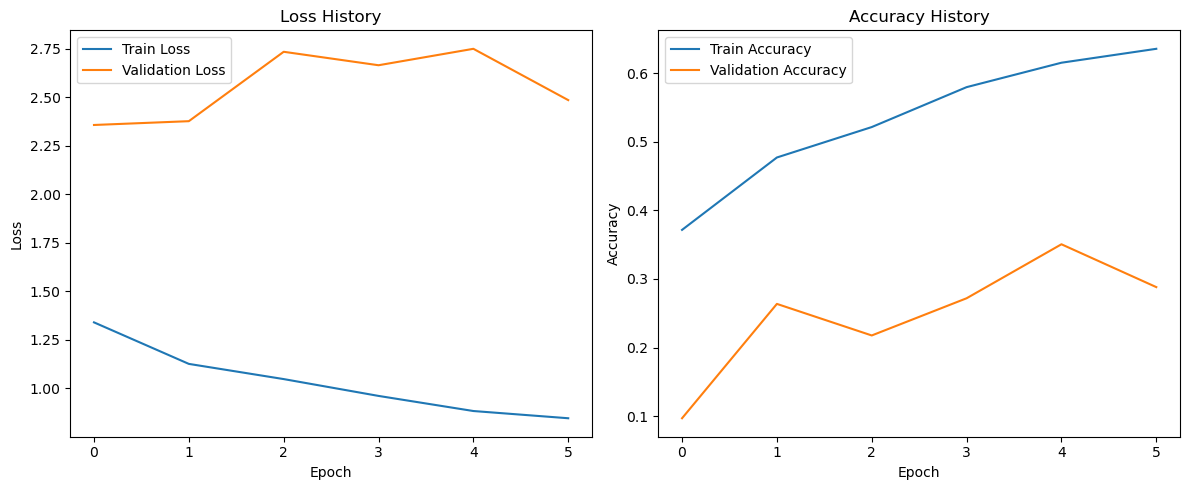

202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


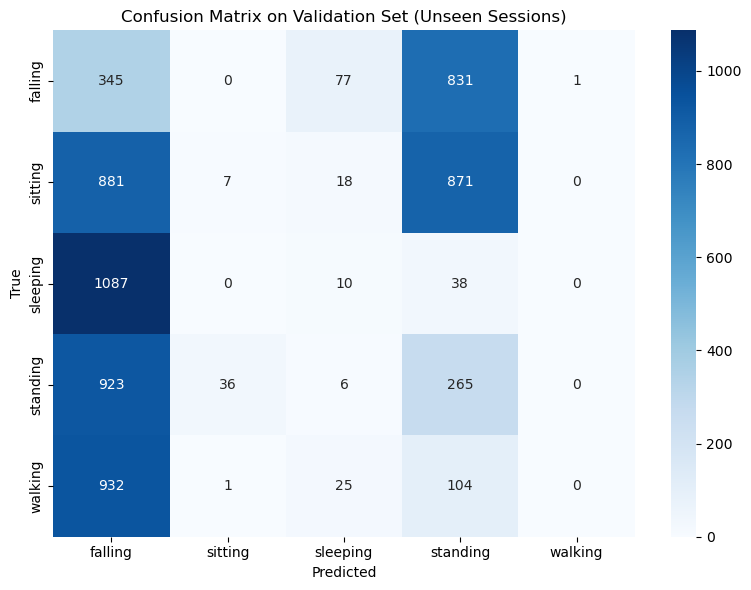


Classification Report on Validation Set (Unseen Sessions):

              precision    recall  f1-score   support

     falling       0.08      0.28      0.13      1254
     sitting       0.16      0.00      0.01      1777
    sleeping       0.07      0.01      0.02      1135
    standing       0.13      0.22      0.16      1230
     walking       0.00      0.00      0.00      1062

    accuracy                           0.10      6458
   macro avg       0.09      0.10      0.06      6458
weighted avg       0.10      0.10      0.06      6458



In [9]:
# --- 8. Evaluate the Model ---
print("\nEvaluating model performance on unseen validation sessions...")

# --- Plot training history ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# --- Confusion Matrix and Report on the Validation Set ---
preds = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Validation Set (Unseen Sessions)")
plt.tight_layout()
plt.show()

print("\nClassification Report on Validation Set (Unseen Sessions):\n")
print(classification_report(y_val, preds, target_names=class_names))